In [50]:
# Import the below libraries:
"""For faster loading, consider importing the libraries in separate cells."""
# To create reproducible file paths
import os # To interact with the operating system
from pathlib import Path # To create Path objects
import pathlib # To access the object-oriented library for paths

# For unzipping folders
import time # To handle time-related tasks
import zipfile # To download and extract zip files

# To use APIs
import requests # For sending API requests

# To download Global Biodiversity Information Facility (GBIF) data
from getpass import getpass # To obtain a GBIF login and password
import pygbif.occurrences as occ # To download species occurrence data from GBIF
import pygbif.species as species # To identify specific species datasets to download on GBIF

# To work with different types of data
import geopandas as gpd # To make GeoDataFrames/work with vector data
from glob import glob # To combine data arrays
from math import floor, ceil # For dealing with integers
import numpy as np # To work with arrays
import pandas as pd # To work with dataframes
import rasterio # For handling raster soil maps
import rioxarray as rxr # To work with raster data
import rioxarray.merge as rxrm # To merge raster data
from shapely.geometry import box # To create bounding boxes
from shapely.geometry import MultiPolygon, Polygon # To handle invalid geometries
import xarray as xr # To use xarray datasets

# For visualization and interactive plotting
from bokeh.plotting import output_file, save as bokeh_save # To save the hvPlot
import contextily as ctx # To restore geography to the base map
import holoviews as hv # To create interactive hvPlots
import hvplot.pandas # To enable hvPlot interactive plotting for Pandas dataframes
import hvplot.xarray # To enable hvPlot interactive plotting for xarray datasets
import matplotlib.gridspec as gridspec # To display the plot legends properly
import matplotlib.pyplot as plt # To import the Pyplot module
import panel as pn # To italicize species' scientific names
import pyproj # For converting axes ticks to degrees

In [2]:
# Create a designated folder to store all repository data
"""Note: the precise destination of the repository folder will vary from individual to individual."""
data_dir = os.path.join(
    pathlib.Path.home(),
    # In the PLANT-B-Terrarium data folder
    'PLANT-B-Terrarium',
    'data',
    # Specify the destination as inside the "PLANT-B-Nutrient-Cycle-Simulation" data repository
    'PLANT-B-Nutrient-Cycle-Simulation',
    'data',
)

# Create the directory
os.makedirs(data_dir, exist_ok=True)

In [3]:
# Create a specific directory inside the data folder for this notebook's data sources
habitat_dir = os.path.join(data_dir, 'soil_habitat_analysis')
os.makedirs(habitat_dir, exist_ok=True)

# Create a folder to store the GBIF data inside the habitat directory
gbif_dir = os.path.join(habitat_dir, 'gbif_PLANT-B_dir')
os.makedirs(gbif_dir, exist_ok=True)

To ensure you stay logged into GBIF, create a file called ".env" in the repository with the following text:

GBIF_USER=[YOUR_GBIF_USERNAME]

GBIF_PWD=[YOUR_GBIF_PASSWORD]

GBIF_EMAIL=[YOUR_GBIF_EMAIL_ADDRESS]

All text in [] should be replaced with the associated values with your GBIF account. When pushing changes to GitHub, ***do not*** include this file.

In [4]:
# Permanently log into GBIF
# Do not reset credentials to avoid repeated login requests
reset_credentials = False

# Request and store username
if (not ('GBIF_USER'  in os.environ)) or reset_credentials:
    os.environ['GBIF_USER'] = input('GBIF username:')

# Request and store password
if (not ('GBIF_PWD'  in os.environ)) or reset_credentials:
    os.environ['GBIF_PWD'] = getpass('GBIF password:')
    
# Request and store email address
if (not ('GBIF_EMAIL'  in os.environ)) or reset_credentials:
    os.environ['GBIF_EMAIL'] = input('GBIF email:')

In [5]:
# Check that the login attempt was successful
'GBIF_PWD' in os.environ

True

In [6]:
# Set the species names for the white dwarf isopod, the temperate white springtail, and the spreading earthmoss:
# White dwarf isopod
isopod_name = "Trichorhina tomentosa"
# Temperate white springtail
springtail_name = "Folsomia candida"
# Spreading earthmoss
moss_name = "Physcomitrium patens"

# Pull the species info from GBIF
isopod_info = species.name_lookup(isopod_name, rank = 'Species')
springtail_info = species.name_lookup(springtail_name, rank = 'Species')
moss_info = species.name_lookup(moss_name, rank = 'Species')

"""Note: Including "\n" before your printed text ensures the results are printed appropriately."""

# Grab the first result for the white dwarf isopod and print it
isopod_result = isopod_info['results'][0]
print("\nWhite dwarf isopod (Trichorhina tomentosa):")
print(isopod_result)

# Grab the second result for the temperate white springtail and print it
"""The second result matches the desired dataset, pulled from https://www.gbif.org/species/2120383."""
springtail_result = springtail_info['results'][1]
print("\nTemperate white springtail (Folsomia candida):")
print(springtail_result)

# Grab the first result for the spreading earthmoss and print it
moss_result = moss_info['results'][0]
print("\nSpreading earthmoss (Physcomitrium patens):")
print(moss_result)


White dwarf isopod (Trichorhina tomentosa):
{'key': 216391800, 'nameKey': 11432545, 'datasetKey': '4cec8fef-f129-4966-89b7-4f8439aba058', 'nubKey': 2204981, 'parentKey': 216391797, 'parent': 'Trichorhina', 'kingdom': 'Animalia', 'phylum': 'Arthropoda', 'order': 'Isopoda', 'family': 'Platyarthridae', 'genus': 'Trichorhina', 'species': 'Trichorhina tomentosa', 'kingdomKey': 157533281, 'phylumKey': 216317629, 'classKey': 216379486, 'orderKey': 216383303, 'familyKey': 216391780, 'genusKey': 216391797, 'speciesKey': 216391800, 'scientificName': 'Trichorhina tomentosa', 'canonicalName': 'Trichorhina tomentosa', 'authorship': '', 'nameType': 'SCIENTIFIC', 'taxonomicStatus': 'ACCEPTED', 'rank': 'SPECIES', 'origin': 'SOURCE', 'numDescendants': 1, 'numOccurrences': 0, 'taxonID': '769260', 'habitats': [], 'nomenclaturalStatus': [], 'threatStatuses': [], 'descriptions': [], 'vernacularNames': [], 'synonym': False, 'higherClassificationMap': {'157533281': 'Animalia', '216317629': 'Arthropoda', '21

In [ ]:
# Get the species key for the dwarf white isopod
isopod_key = isopod_result['nubKey']

# Check what the isopod's species key is
isopod_name, isopod_key

('Trichorhina tomentosa', 2204981)

In [8]:
# Get the species key for the temperate white springtail
springtail_key = springtail_result['nubKey']

# Check what the springtail's species key is
springtail_name, springtail_key

('Folsomia candida', 2120383)

In [9]:
# Get the species key for the spreading earthmoss
moss_key = moss_result['nubKey']

# Check what the moss's species key is
moss_name, moss_key

('Physcomitrium patens', 8179907)

In [ ]:
# Create a directory to store the isopod GBIF data
isopod_gbif_dir = os.path.join(gbif_dir, 'isopod_gbif_dir')
os.makedirs(isopod_gbif_dir, exist_ok=True)

# Create the file path for the isopod CSV
isopod_gbif_pattern = os.path.join(isopod_gbif_dir, '*.csv')

# Create a function to download the dwarf white isopod occurrence data:
if not glob(isopod_gbif_pattern): # For the isopod data download, ensure the pattern used is "isopod_gbif_pattern"
    """
    Each download function must be given distinct pattern, data query, download key, and CSV path variables to avoid downloading the same 
    GBIF dataset.

    Parameters:
    isopod_gbif_query: GBIF query specific to the isopod download function
    isopod_download_key: Download key for the isopod GBIF download
    isopod_gbif_path: CSV file path for the isopod data download

    Returns: 
    isopod_gbif_pattern: File name for the isopod GBIF CSV
    """
    # Submit the query to GBIF
    isopod_gbif_query = occ.download([
        f"speciesKey = {isopod_key}", # For the isopod data download, ensure the key used is "isopod_key"
        "hasCoordinate = True", # For all datasets, only accept occurrence points that have longitude and latitude coordinates
    ])

    # Only download the data once
    isopod_download_key = isopod_gbif_query[0]
    os.environ['GBIF_DOWNLOAD_KEY'] = isopod_download_key
    time.sleep(5) # Let it rest before reattempting the download

    # Download the data
    isopod_download_info = occ.download_get(
        isopod_download_key,
        path = isopod_gbif_dir
    )
    
    # Unzip the file
    with zipfile.ZipFile(isopod_download_info['path']) as download_zip:
        download_zip.extractall(path = isopod_gbif_dir)

# Locate the CSV file path for the isopod data download
isopod_gbif_path = glob(isopod_gbif_pattern)[0]

INFO:Your download key is 0005649-260721160103020
INFO:Download file size: 13114 bytes
INFO:On disk at C:\Users\livth\PLANT-B-Terrarium\data\PLANT-B-Nutrient-Cycle-Simulation\data\soil_habitat_analysis\gbif_PLANT-B_dir\isopod_gbif_dir/0005649-260721160103020.zip


In [12]:
# Look at the isopod download information
occ.download_meta("0005649-260721160103020") # Input the download key to view the information

{'key': '0005649-260721160103020',
 'doi': '10.15468/dl.y76gsf',
 'license': 'http://creativecommons.org/licenses/by-nc/4.0/legalcode',
 'request': {'predicate': {'type': 'and',
   'predicates': [{'type': 'equals',
     'key': 'SPECIES_KEY',
     'value': '2204981',
     'matchCase': False},
    {'type': 'equals',
     'key': 'HAS_COORDINATE',
     'value': 'True',
     'matchCase': False}]},
  'sendNotification': True,
  'format': 'SIMPLE_CSV',
  'type': 'OCCURRENCE',
  'verbatimExtensions': [],
  'interpretedExtensions': []},
 'created': '2026-07-24T03:56:48.505+00:00',
 'modified': '2026-07-24T03:58:26.639+00:00',
 'eraseAfter': '2027-01-24T03:56:48.408+00:00',
 'status': 'SUCCEEDED',
 'downloadLink': 'https://api.gbif.org/v1/occurrence/download/request/0005649-260721160103020.zip',
 'size': 13114,
 'totalRecords': 140,
 'numberDatasets': 27}

In [13]:
# Read the isopod CSV
isopod_gbif_df = pd.read_csv(
    isopod_gbif_path,
    delimiter = '\t'
)

# Check the dataframe
isopod_gbif_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,6361602303,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626605,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Salvador, Rodrigo B.;Laine, Veronika;Hanwell, ...",NaN,NaN,2026-07-20T10:53:56.349Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
1,6361602301,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626497,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Saarinen, Veera;Hanwell, Mari-Hanna;Salvador, ...",NaN,NaN,2026-07-20T10:53:56.913Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
2,6361601301,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626529,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Saarinen, Veera;Salvador, Rodrigo B.;Hanwell, ...",NaN,NaN,2026-07-20T10:53:56.898Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
3,6361600301,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626509,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Salvador, Rodrigo B.;Hanwell, Mari-Hanna;Saari...",NaN,NaN,2026-07-20T10:53:56.685Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
4,6181601810,9a0b66df-7535-4f28-9f4e-5bc11b8b096c,Natuurpunt:Waarnemingen:388844367,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Natuurpunt Studie,NaN,NaN,NaN,2026-07-22T12:09:45.915Z,NaN,OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COU...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,1318795009,821cc27a-e3bb-4bc5-ac34-89ada245069d,http://n2t.net/ark:/65665/3466b26b7-27f5-4fa7-...,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,Verhoeff,NaN,CC0_1_0,NaN,Verhoeff,NaN,NaN,2026-07-18T17:25:58.478Z,StillImage,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...
136,1054185903,2e4cc37b-302e-4f1b-bbbb-1f674ff90e14,28417,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Olsen, K.M.",NaN,CC_BY_4_0,NaN,"Olsen, K.M.",NaN,NaN,2026-07-23T12:51:12.104Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
137,1054185717,2e4cc37b-302e-4f1b-bbbb-1f674ff90e14,28203,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Olsen, K.M.",NaN,CC_BY_4_0,NaN,"Olsen, K.M.",NaN,NaN,2026-07-23T12:51:10.982Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
138,1054177305,2e4cc37b-302e-4f1b-bbbb-1f674ff90e14,08000,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Olsen, K.M.",NaN,CC_BY_4_0,NaN,"Olsen, K.M.",NaN,NaN,2026-07-23T12:51:10.803Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...


In [18]:
# Create a directory to store the springtail GBIF data
springtail_gbif_dir = os.path.join(gbif_dir, 'springtail_gbif_dir')
os.makedirs(springtail_gbif_dir, exist_ok=True)

# Create the file path for the springtail CSV
springtail_gbif_pattern = os.path.join(springtail_gbif_dir, '*.csv')

# Create a function to download the temperate white springtail occurrence data
if not glob(springtail_gbif_pattern): # For the springtail data download, ensure the pattern used is "springtail_gbif_pattern"
    """
    Each download function must be given distinct pattern, data query, download key, and CSV path variables to avoid downloading the same
    GBIF dataset.

    Parameters:
    springtail_gbif_query: GBIF query specific to the springtail download function
    springtail_download_key: Download key for the springtail GBIF download
    springtail_gbif_path: CSV file path for the springtail data download

    Returns: 
    springtail_gbif_pattern: File name for the springtail GBIF CSV
    """
    # Submit the query to GBIF
    springtail_gbif_query = occ.download([
        f"speciesKey = {springtail_key}", # For the springtail data download, ensure the key used is "springtail_key"
        "hasCoordinate = True", # For all datasets, only accept occurrence points that have longitude and latitude coordinates
    ])

    # Only download the data once
    springtail_download_key = springtail_gbif_query[0]
    os.environ['GBIF_DOWNLOAD_KEY'] = springtail_download_key
    time.sleep(5) # Let it rest before reattempting the download

    # Download the data
    springtail_download_info = occ.download_get(
        springtail_download_key,
        path = springtail_gbif_dir
    )
    
    # Unzip the file
    with zipfile.ZipFile(springtail_download_info['path']) as download_zip:
        download_zip.extractall(path = springtail_gbif_dir)

# Locate the CSV file path for the springtail data download
springtail_gbif_path = glob(springtail_gbif_pattern)[0]

INFO:Your download key is 0005662-260721160103020
INFO:Download file size: 61328 bytes
INFO:On disk at C:\Users\livth\PLANT-B-Terrarium\data\PLANT-B-Nutrient-Cycle-Simulation\data\soil_habitat_analysis\gbif_PLANT-B_dir\springtail_gbif_dir/0005662-260721160103020.zip


In [19]:
# Look at the springtail download information
occ.download_meta("0005662-260721160103020") # Input the download key to view the information

{'key': '0005662-260721160103020',
 'doi': '10.15468/dl.7x6zk3',
 'license': 'http://creativecommons.org/licenses/by-nc/4.0/legalcode',
 'request': {'predicate': {'type': 'and',
   'predicates': [{'type': 'equals',
     'key': 'SPECIES_KEY',
     'value': '2120383',
     'matchCase': False},
    {'type': 'equals',
     'key': 'HAS_COORDINATE',
     'value': 'True',
     'matchCase': False}]},
  'sendNotification': True,
  'format': 'SIMPLE_CSV',
  'type': 'OCCURRENCE',
  'verbatimExtensions': [],
  'interpretedExtensions': []},
 'created': '2026-07-24T04:04:43.182+00:00',
 'modified': '2026-07-24T04:06:21.563+00:00',
 'eraseAfter': '2027-01-24T04:04:43.027+00:00',
 'status': 'SUCCEEDED',
 'downloadLink': 'https://api.gbif.org/v1/occurrence/download/request/0005662-260721160103020.zip',
 'size': 61328,
 'totalRecords': 1390,
 'numberDatasets': 104}

In [20]:
# Read the springtail CSV
springtail_gbif_df = pd.read_csv(
    springtail_gbif_path,
    delimiter = '\t'
)

# Check the dataframe
springtail_gbif_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,920117266,f02240a8-f206-467b-a379-fdce36beb808,97734,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-07-18T16:27:43.245Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
1,920117240,f02240a8-f206-467b-a379-fdce36beb808,97733,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-07-18T16:27:43.237Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
2,920117215,f02240a8-f206-467b-a379-fdce36beb808,97732,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-07-18T16:27:43.233Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
3,920117190,f02240a8-f206-467b-a379-fdce36beb808,97731,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-07-18T16:27:43.226Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
4,920094047,30eca5bd-6a4f-46de-9e6f-d6ede90850dc,10251,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-07-18T15:20:45.092Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1385,1414818304,040c5662-da76-4782-a48e-cdea1892d14c,COLLF950-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-07-23T14:58:51.187Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...
1386,1414818213,040c5662-da76-4782-a48e-cdea1892d14c,COLLF945-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-07-23T14:58:52.325Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...
1387,1414818175,040c5662-da76-4782-a48e-cdea1892d14c,COLLF949-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-07-23T14:58:54.333Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...
1388,1414818168,040c5662-da76-4782-a48e-cdea1892d14c,COLLF946-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-07-23T14:54:36.463Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...


In [23]:
# Create a directory to store the moss GBIF data
moss_gbif_dir = os.path.join(gbif_dir, 'moss_gbif_dir')
os.makedirs(moss_gbif_dir, exist_ok=True)

# Create the file path for the moss CSV
moss_gbif_pattern = os.path.join(moss_gbif_dir, '*.csv')

# Create a function to download the spreading earthmoss occurrence data

if not glob(moss_gbif_pattern): # For the moss data download, ensure the pattern used is "moss_gbif_pattern"
    """
    Each download function must be given distinct pattern, data query, download key, and CSV path variables to avoid downloading the same 
    GBIF dataset.

    Parameters:
    moss_gbif_query: GBIF query specific to the moss download function
    moss_download_key: Download key for the moss GBIF download
    moss_gbif_path: CSV file path for the moss data download

    Returns: 
    moss_gbif_pattern: File name for the moss GBIF CSV
    """
    # Submit the query to GBIF
    moss_gbif_query = occ.download([
        f"speciesKey = {moss_key}", # For the moss data download, ensure the key used is "moss_key"
        "hasCoordinate = True", # For all datasets, only accept occurrence points that have longitude and latitude coordinates
    ])

    # Only download the data once
    moss_download_key = moss_gbif_query[0]
    os.environ['GBIF_DOWNLOAD_KEY'] = moss_download_key
    time.sleep(5) # Let it rest before reattempting the download

    # Download the data
    moss_download_info = occ.download_get(
        moss_download_key,
        path = moss_gbif_dir
    )
    
    # Unzip the file
    with zipfile.ZipFile(moss_download_info['path']) as download_zip:
        download_zip.extractall(path = moss_gbif_dir)

# Locate the CSV file path for the moss data download
moss_gbif_path = glob(moss_gbif_pattern)[0]

INFO:Your download key is 0005671-260721160103020
INFO:Download file size: 231982 bytes
INFO:On disk at C:\Users\livth\PLANT-B-Terrarium\data\PLANT-B-Nutrient-Cycle-Simulation\data\soil_habitat_analysis\gbif_PLANT-B_dir\moss_gbif_dir/0005671-260721160103020.zip


In [24]:
# Look at the moss download information
occ.download_meta("0003437-260623161305970") # Input the download key to view the information

{'key': '0003437-260623161305970',
 'doi': '10.15468/dl.kcg8ac',
 'license': 'http://creativecommons.org/licenses/by-nc/4.0/legalcode',
 'request': {'predicate': {'type': 'and',
   'predicates': [{'type': 'equals',
     'key': 'SPECIES_KEY',
     'value': '8179907',
     'matchCase': False},
    {'type': 'equals',
     'key': 'HAS_COORDINATE',
     'value': 'True',
     'matchCase': False}]},
  'sendNotification': True,
  'format': 'SIMPLE_CSV',
  'type': 'OCCURRENCE',
  'verbatimExtensions': [],
  'interpretedExtensions': []},
 'created': '2026-06-26T20:28:35.380+00:00',
 'modified': '2026-06-26T20:30:12.748+00:00',
 'eraseAfter': '2026-12-26T20:28:35.201+00:00',
 'status': 'SUCCEEDED',
 'downloadLink': 'https://api.gbif.org/v1/occurrence/download/request/0003437-260623161305970.zip',
 'size': 232554,
 'totalRecords': 3026,
 'numberDatasets': 163}

In [25]:
# Read the moss CSV
moss_gbif_df = pd.read_csv(
    moss_gbif_path,
    delimiter = '\t'
)

# Check the dataframe
moss_gbif_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,875069810,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:7011835,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Niklas Lönnell,Niklas Lönnell,NaN,NaN,2026-07-20T15:49:11.420Z,NaN,NaN
1,875040473,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:7004615,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Niklas Lönnell,Niklas Lönnell,NaN,NaN,2026-07-20T15:47:57.586Z,NaN,NaN
2,875040321,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:7004617,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Niklas Lönnell,Niklas Lönnell,NaN,NaN,2026-07-20T15:52:52.585Z,NaN,NaN
3,855982923,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:335180,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Tommy Knutsson,Via Tommy Knutsson,NaN,NaN,2026-07-20T15:45:18.578Z,NaN,INSTITUTION_MATCH_NONE
4,855901418,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:335577,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Henrik Weibull,"Henrik Weibull, Karin Wiklund, Henry Åkerström",NaN,NaN,2026-07-20T15:45:08.974Z,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035,1038470363,e88fdc62-ea3b-41a3-8967-b3780f602c0b,NaN,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,S. Caspari,NaN,CC_BY_4_0,NaN,R. Düll,NaN,NaN,2026-07-18T15:24:25.288Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
3036,1036706845,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:16591519,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Tomas Hallingbäck,Tomas Hallingbäck,NaN,NaN,2026-07-20T15:52:39.186Z,NaN,NaN
3037,1020051494,bfaa049a-90cd-412d-9660-5380591ba4a5,3cb08128-cc5f-4776-ab22-bcfe3713fe8d,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-07-18T16:55:04.021Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...
3038,1020051492,bfaa049a-90cd-412d-9660-5380591ba4a5,e47803f0-76e6-42c6-a029-7d8e338a33d0,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-07-18T16:55:04.021Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...


In [26]:
# Combine all three dataframes
terrarium_species_df = pd.concat(
    [isopod_gbif_df, springtail_gbif_df, moss_gbif_df],
    ignore_index=True
)

# Check the dataframe
terrarium_species_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,6361602303,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626605,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Salvador, Rodrigo B.;Laine, Veronika;Hanwell, ...",NaN,NaN,2026-07-20T10:53:56.349Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
1,6361602301,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626497,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Saarinen, Veera;Hanwell, Mari-Hanna;Salvador, ...",NaN,NaN,2026-07-20T10:53:56.913Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
2,6361601301,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626529,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Saarinen, Veera;Salvador, Rodrigo B.;Hanwell, ...",NaN,NaN,2026-07-20T10:53:56.898Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
3,6361600301,d185ab72-3518-4cb8-b9ad-79010d6eef70,http://id.luomus.fi/MY.19626509,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Pajunen, Timo",NaN,CC_BY_4_0,NaN,"Salvador, Rodrigo B.;Hanwell, Mari-Hanna;Saari...",NaN,NaN,2026-07-20T10:53:56.685Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;TAXON_CONCE...
4,6181601810,9a0b66df-7535-4f28-9f4e-5bc11b8b096c,Natuurpunt:Waarnemingen:388844367,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Natuurpunt Studie,NaN,NaN,NaN,2026-07-22T12:09:45.915Z,NaN,OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COU...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4565,1038470363,e88fdc62-ea3b-41a3-8967-b3780f602c0b,NaN,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,S. Caspari,NaN,CC_BY_4_0,NaN,R. Düll,NaN,NaN,2026-07-18T15:24:25.288Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
4566,1036706845,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:16591519,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Tomas Hallingbäck,Tomas Hallingbäck,NaN,NaN,2026-07-20T15:52:39.186Z,NaN,NaN
4567,1020051494,bfaa049a-90cd-412d-9660-5380591ba4a5,3cb08128-cc5f-4776-ab22-bcfe3713fe8d,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-07-18T16:55:04.021Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...
4568,1020051492,bfaa049a-90cd-412d-9660-5380591ba4a5,e47803f0-76e6-42c6-a029-7d8e338a33d0,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-07-18T16:55:04.021Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...


In [27]:
# Specify the columns to keep
"""Only columns related to the species name, geometry, and observation date will be kept."""
columns_to_keep = [
    'species', 'decimalLatitude', 'decimalLongitude','eventDate'
]

# Filter the dataset to keep only the necessary columns
gbif_filtered_df = terrarium_species_df[columns_to_keep]

# Remove observations that do not have coordinates
clean_gbif_gdf = gbif_filtered_df.dropna(subset=['decimalLatitude', 'decimalLongitude'])

# Convert the filtered dataframe into a GeoDataFrame (GDF)
gbif_gdf = gpd.GeoDataFrame(
    clean_gbif_gdf,
    # Add geometry columns to convert to a GDF
    geometry = gpd.points_from_xy(
        clean_gbif_gdf.decimalLongitude,
        clean_gbif_gdf.decimalLatitude
    ),
    crs = 'EPSG:4326'  # Set the Coordinate Reference System (CRS)
)

# Group all spreading earthmoss sightings under the updated scientific name "Physcomitrium patens"
gbif_gdf['species'] = gbif_gdf['species'].replace({'Physcomitrella patens': 'Physcomitrium patens'})

# Display the GDF data
gbif_gdf

,species,decimalLatitude,decimalLongitude,eventDate,geometry
0,Trichorhina tomentosa,60.175345,24.945762,2025-09-20T00:00Z,POINT (24.94576 60.17534)
1,Trichorhina tomentosa,60.175345,24.945762,2025-10-22T00:00Z,POINT (24.94576 60.17534)
2,Trichorhina tomentosa,60.175345,24.945762,2025-10-22T00:00Z,POINT (24.94576 60.17534)
3,Trichorhina tomentosa,60.175345,24.945762,2025-10-22T00:00Z,POINT (24.94576 60.17534)
4,Trichorhina tomentosa,51.034900,3.723300,2026-03-18,POINT (3.7233 51.0349)
...,...,...,...,...,...
4565,Physcomitrium patens,49.674896,7.374754,1977-10-16,POINT (7.37475 49.6749)
4566,Physcomitrium patens,59.716040,17.815800,2014-09-16,POINT (17.8158 59.71604)
4567,Physcomitrium patens,54.525390,-1.554315,1797-01-01/1831-12-31,POINT (-1.55432 54.52539)
4568,Physcomitrium patens,55.004807,-2.570055,1797-01-01/1831-12-31,POINT (-2.57006 55.00481)


In [28]:
# Create a path to save gbif_gdf as a CSV in gbif_dir
gbif_csv_path = os.path.join(gbif_dir, "gbif_gdf.csv")

# Save gbif_gdf as a CSV
gbif_gdf.to_csv(gbif_csv_path, index=False)

In [48]:
# Set the parameters for the hvPlot
species_distribution_plot = gbif_gdf.hvplot(
    c="species",  # Color the points so they are identified by species
    cmap="Dark2",  # Set the color map
    crs="EPSG:4326", # Set the CRS to ESPG:4326
    # Set the width and height
    frame_height=400,
    frame_width=650,
    geo=True,
    hover_cols=["species"], # Make the species visible when a point is hovered over
    tiles="EsriWorldStreetMap", # Use "EsriWorldStreetMap" to ensure country names are in English
    title=f'Distribution of PLANT-B Species', # Set the title
    x="decimalLongitude", # Define the x-axis by the longitude
    y="decimalLatitude", # Define the y-axis by the latitude
)

# Render the hvPlot to an actual Bokeh figure
interactive_species_plot = hv.render(species_distribution_plot)

# Increase the title's font size
interactive_species_plot.title.text_font_size = "12pt"

# Italicize the species' scientific names
for legend in interactive_species_plot.legend:
    legend.label_text_font_style = "italic"

# Display with the species distribution plot with Panel
pn.pane.Bokeh(interactive_species_plot)

BokehModel(combine_events=True, render_bundle={'docs_json': {'95118bf3-560b-4458-971d-373e97fe54e8': {'version…

In [51]:
# Establish the main repository directory
root_dir = os.path.dirname(data_dir)

# Create a directory to store the plots
plots_dir = os.path.join(root_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)

# Create a path to save the species distribution plot in the "plots" folder
species_distribution_plot_path = Path(plots_dir) / "Interactive_PLANT-B_Species_Distribution_Plot.html"

# Save the plot as an interactive HTML
if not species_distribution_plot_path.exists():
    output_file(species_distribution_plot_path, title="Distribution of PLANT-B Species")
    bokeh_save(interactive_species_plot)
else:
    print("The interactive plot showing the distribution of PLANT-B's chosen species has already been saved.")

In [53]:
# Define the bounding box boundary so it is in the chosen area near the Germany-Poland boundary
minx, miny, maxx, maxy = 14.05, 50.92, 15.05, 51.32

# Clip the GDF to the bounding box
clipped_gbif_gdf = gbif_gdf.cx[minx:maxx, miny:maxy]

# Display all observations within the bounding box
clipped_gbif_gdf

,species,decimalLatitude,decimalLongitude,eventDate,geometry
58,Trichorhina tomentosa,51.150305,14.926473,NaN,POINT (14.92647 51.1503)
740,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
741,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
743,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)
744,Folsomia candida,50.948821,14.914726,1989-09-20,POINT (14.91473 50.94882)
745,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)
746,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)
747,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
748,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
749,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)


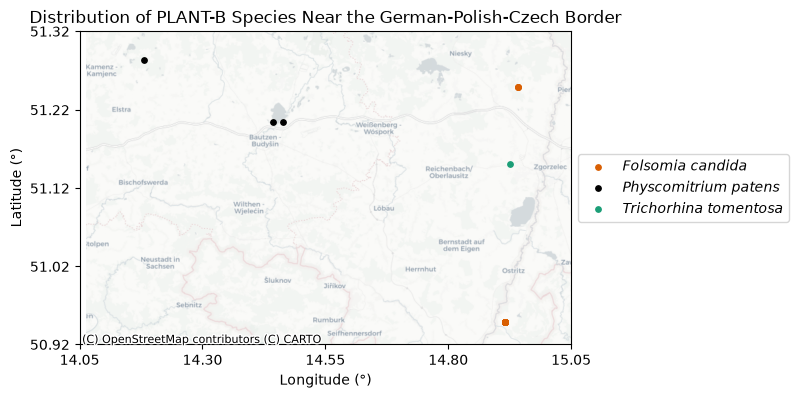

In [59]:
# Create a function that produces a Matplotlib plot of the observations along the border:
def plot_species_distribution(
    clipped_gbif_gdf,
    minx,
    miny,
    maxx,
    maxy,
    figsize=(8, 6),
    title="Distribution of PLANT-B Species Near the German-Polish-Czech Border"
):
    """
    Parameters:
    clipped_gbif_gdf: A GDF clipped to a bounding box encompassing the target area
    minx: Westernmost longitude coordinate
    miny: Southernmost latitude coordinate
    maxx: Easternmost longitude coordinate
    maxy: Northernmost latitude coordinate
    figsize: The size of the plot
    title: The title of the plot

    Returns:
    Non-interactive Matplotlib plot of the three species observations near the German-Polish-Czech Border
    """
    # Set the species colors to match the hvPlot points
    species_colors = {
        # Green for the dwarf white isopod
        "Trichorhina tomentosa": "#1b9e77",
        # Dark orange for the temperate white springtail
        "Folsomia candida": "#d95f02",
        # Purple for the spreading earthmoss
        "Physcomitrella patens": "#7570b3"
    }

    # Set the figure size
    fig, ax = plt.subplots(figsize=figsize)

    # Reproject the GDF to match an EPSG of 3857
    gbif_gdf_map = clipped_gbif_gdf.to_crs(epsg=3857)

    # Plot each species on the map
    for species, species_border_gdf in gbif_gdf_map.groupby("species"):
        species_border_gdf.plot(
            ax=ax,
            color=species_colors.get(species, "black"), # Ensure each species keeps their designated color
            label=species, # The point label will match the species name
            markersize=15
        )

    # Add the basemap background using contextily
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Add labels for the titles and axes
    ax.set_title(title) # The title is already specified in the parameters section of the function
    ax.set_xlabel("Longitude (°)") # The x-axis will correspond to longitude
    ax.set_ylabel("Latitude (°)") # The y-axis will correspond to latitude

    # Add the species legend outside the plot map
    ax.legend(
        loc="center left", # Anchor the legend on its left side
        bbox_to_anchor=(1, 0.5), # Move the anchor just outside the plot map 
        prop={"style": "italic"},  # Italicize the species names in the legend
        frameon=True
    )

    # Apply a tight layout to avoid clipping the legend
    plt.tight_layout()

    # Generate evenly spaced longitude and latitude ticks in degrees
    xticks = np.linspace(minx, maxx, 5)
    yticks = np.linspace(miny, maxy, 5)

    # Create a transformer to turn the x- and y-axis units back to degrees
    transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    # Convert the x-axis and y-axis tick positions to the projected coordinate system using the transformer
    xticks_3857, _ = transformer.transform(xticks, np.full_like(xticks, miny))
    _, yticks_3857 = transformer.transform(np.full_like(yticks, minx), yticks)

    # Place the ticks at the correct positions on the projected map, labeled in degrees
    ax.set_xticks(xticks_3857)
    ax.set_yticks(yticks_3857)
    ax.set_xticklabels([f"{x:.2f}" for x in xticks])
    ax.set_yticklabels([f"{y:.2f}" for y in yticks])

    # Save the plot as a png image to the "plots" folder
    plt.savefig(
        os.path.join(plots_dir, "PLANT-B_Species_Border_Distribution_Plot.png"),
        dpi=300,
        bbox_inches="tight"
    )

    # Show the plot
    plt.show()

    # Return the figure and axes
    return fig, ax

# Call the function
fig, ax = plot_species_distribution(
    clipped_gbif_gdf,
    minx,
    miny,
    maxx,
    maxy
)

The data from the Land Use and Coverage Area frame Survey (LUCAS) 2018 TOPSOIL dataset cannot be downloaded with a function. A request form must be filled out at https://esdac.jrc.ec.europa.eu/content/lucas-2018-topsoil-data#tabs-0-description=1 so the dataset can be emailed to you. Move the provided folders into the "soil_nutrient_dir" inside the "soil_dir," which will be created below.

In [57]:
# Create a new directory in nutrient_data_dir to store the soil nutrient and microbe data
soil_dir = os.path.join(habitat_dir, 'soil_dir')
os.makedirs(soil_dir, exist_ok=True) 

# Inside soil_dir, create a new directory to store the soil nutrient data
soil_nutrient_dir = os.path.join(soil_dir, 'soil_nutrient_dir')
os.makedirs(soil_nutrient_dir, exist_ok=True)

# Create a variable for the downloaded "LUCAS-SOIL-2018-V2" folder
lucas_soil_dir = os.path.join(soil_nutrient_dir, 'LUCAS-SOIL-2018-V2')
os.makedirs(lucas_soil_dir, exist_ok=True)

# Create a path to the downloaded topsoil data CSV
soil_nutrient_csv_path = os.path.join(lucas_soil_dir, "LUCAS-SOIL-2018.csv")

# Define the CSV as a dataframe
soil_nutrient_df = pd.read_csv(
    soil_nutrient_csv_path,
    sep=','
)

# View the data available in the CSV
soil_nutrient_df

,Depth,POINTID,pH_CaCl2,pH_H2O,EC,OC,CaCO3,P,N,K,...,NUTS_3,TH_LAT,TH_LONG,SURVEY_DATE,Elev,LC,LU,LC0_Desc,LC1_Desc,LU1_Desc
0,0-20 cm,47862690,4.1,4.81,8.73,12.4,3,< LOD,1.1,101.9,...,AT113,47.150238,16.134212,06-07-18,291,C23,U120,Woodland,Other coniferous woodland,Forestry
1,0-20 cm,47882704,4.1,4.93,5.06,16.7,1,< LOD,1.3,51.2,...,AT113,47.274272,16.175359,06-07-18,373,C21,U120,Woodland,Spruce dominated coniferous woodland,Forestry
2,0-20 cm,47982688,4.1,4.85,12.53,47.5,1,12.3,3.1,114.8,...,AT113,47.123260,16.289693,02-06-18,246,C33,U120,Woodland,Other mixed woodland,Forestry
3,0-20 cm,48022702,5.5,5.80,21.10,28.1,3,< LOD,2,165.8,...,AT113,47.245693,16.357506,06-07-18,305,C22,U120,Woodland,Pine dominated coniferous woodland,Forestry
4,0-20 cm,48062708,6.1,6.48,10.89,19.4,2,< LOD,2.2,42.1,...,AT113,47.296372,16.416782,05-07-18,335,C22,U120,Woodland,Pine dominated coniferous woodland,Forestry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18979,0-20 cm,32643634,6.0,6.13,91.40,51.4,2,92.2,5.3,1036.9,...,UKN11,54.713343,-6.563749,24-07-18,50,E20,U111,Grassland,Grassland without tree/shrub cover,Agriculture (excluding fallow land and kitchen...
18980,0-20 cm,32703676,4.9,5.14,51.78,73.9,NaN,81.6,6.9,225,...,UKN12,55.091488,-6.625119,02-08-18,34,B55,U111,Cropland,Temporary grassland,Agriculture (excluding fallow land and kitchen...
18981,0-20 cm,32783608,5.5,5.94,22.40,63.7,1,101.9,6.7,569.5,...,UKN14,54.515104,-6.259448,18-06-18,50,E20,U111,Grassland,Grassland without tree/shrub cover,Agriculture (excluding fallow land and kitchen...
18982,0-20 cm,32783636,5.3,5.90,10.42,38.3,1,7.3,3.1,1907.9,...,UKN13,54.759266,-6.358608,05-06-18,122,E20,U370,Grassland,Grassland without tree/shrub cover,Residential


In [58]:
# Subset samples within the bounding box
border_sample = soil_nutrient_df[
    (soil_nutrient_df["TH_LONG"] >= minx) &
    (soil_nutrient_df["TH_LONG"] <= maxx) &
    (soil_nutrient_df["TH_LAT"] >= miny) &
    (soil_nutrient_df["TH_LAT"] <= maxy)
]

# View the samples taken within the bounding box
border_sample

,Depth,POINTID,pH_CaCl2,pH_H2O,EC,OC,CaCO3,P,N,K,...,NUTS_3,TH_LAT,TH_LONG,SURVEY_DATE,Elev,LC,LU,LC0_Desc,LC1_Desc,LU1_Desc
1436,0-20 cm,46363102,5.1,5.82,5.96,21.7,NaN,57.3,2.2,80.8,...,CZ042,50.942446,14.484925,03-09-18,427,E20,U111,Grassland,Grassland without tree/shrub cover,Agriculture (excluding fallow land and kitchen...


In [60]:
# Extract the single sample
sample = border_sample.iloc[0]

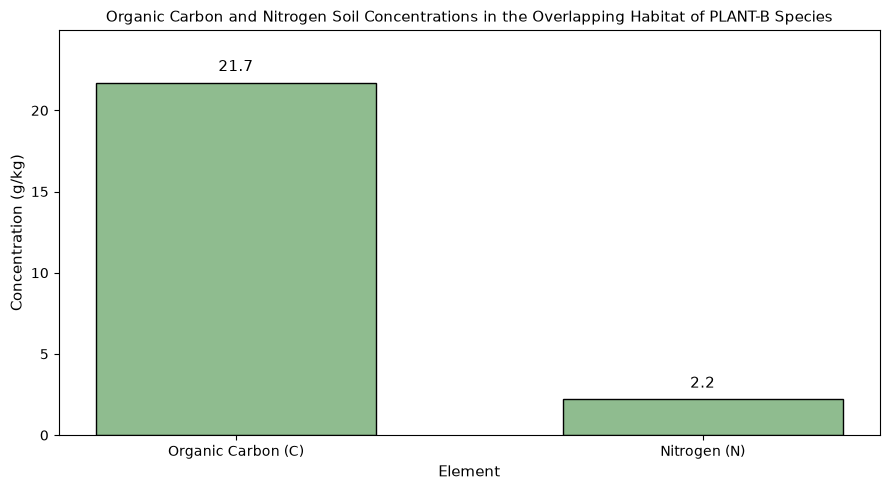

In [61]:
# Create a function that plots a bar chart showing organic carbon and nitrogen concentrations in the habitat:
def c_n_plot (sample):
    """
    Parameters:
    sample: Soil sample taken within the bounding box area
    
    Returns:
    A bar chart that shows organic carbon and nitrogen concentrations in the overlapping habitat in g/kg
    """
    # Alter the labels so the nutrients' full names are displayed
    c_n = {
        'OC': 'Organic Carbon (C)',
        'N': 'Nitrogen (N)'
    }

    # Extract and convert the nutrient values
    values = pd.to_numeric(sample[list(c_n.keys())], errors='coerce')

    # Substitute in the full names
    values.index = [c_n[k] for k in values.index]

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 5))

    # Plot the nutrient values as bars
    bars = ax.bar(
        values.index,
        values.values,
        color='darkseagreen', # Set the bar color
        edgecolor='black', # Set the edge color
        width=0.6 # Set the bar width
)

    # Add the numeric nutrient concentrations to the top of the bars
    # Add value labels on top of each bar
    for bar, val in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=11
        )
    
    # Set the title
    ax.set_title(
        f'Organic Carbon and Nitrogen Soil Concentrations in the Overlapping Habitat of PLANT-B Species',
        fontsize=11
    )

    # Label the x- and y-axis and set their font size
    ax.set_xlabel('Element', fontsize=11)
    ax.set_ylabel('Concentration (g/kg)', fontsize=11)

    # Add room so the tallest bar label does not overlap with the top of the bar chart
    ax.set_ylim(0, values.max() * 1.15)

    # Apply a tight layout
    plt.tight_layout()

    # Save the plot as a png image to the "plots" folder
    plt.savefig(
        os.path.join(plots_dir, "PLANT-B_Species_Overlapping_Habitat_OC_and_N_Concentrations_Plot.png"),
        dpi=300,
        bbox_inches="tight"
    )

    # Display the bar chart
    plt.show()

    # Return the figure and axes
    return fig, ax

# Call the function
fig, ax = c_n_plot(
    sample
)

In [64]:
# Create a variable for the organic carbon mass
soil_oc = float(border_sample.loc[border_sample['POINTID'] == 46363102, 'OC'].iloc[0])

# Create a variable for the nitrogen mass
soil_n = float(border_sample.loc[border_sample['POINTID'] == 46363102, 'N'].iloc[0])

# Caclulate the C:N ratio of the soil sample
soil_c_n_ratio = soil_oc / soil_n

# Print the variables
print("Carbon (C) soil concentration (g/kg):")
print(soil_oc)

print("\nNitrogen (N) soil concentration (gg/kg):")
print(soil_n)

print("\nC:N ratio of the soil sample:")
print(soil_c_n_ratio)

Carbon (C) soil concentration (g/kg):
21.7

Nitrogen (N) soil concentration (gg/kg):
2.2

C:N ratio of the soil sample:
9.863636363636363


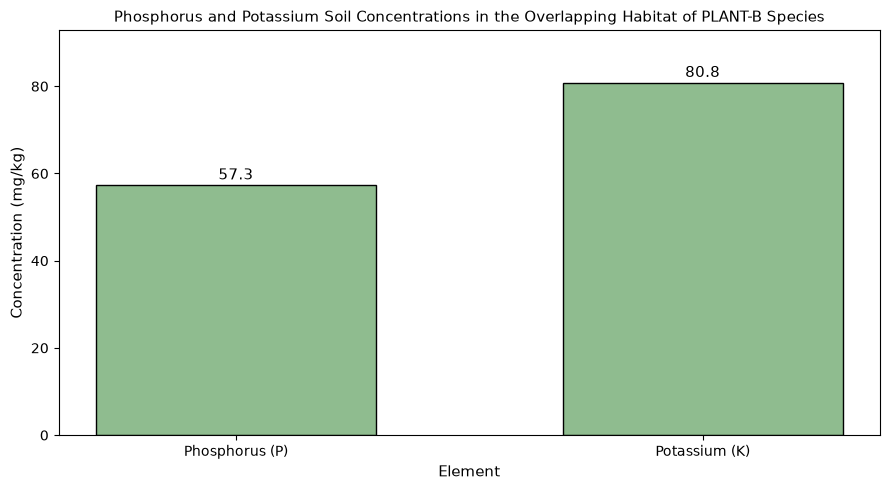

In [65]:
# Create a function that plots a bar chart showing phosphorus and potassium concentrations in the habitat:
def p_k_plot (sample):
    """
    Parameters:
    sample: Soil sample taken within the bounding box area
    
    Returns:
    A bar chart that shows phosphorus and potassium concentrations in the overlapping habitat in mg/kg
    """
    # Alter the labels so the p_k' full names are displayed
    p_k = {
        'P':'Phosphorus (P)',
        'K': 'Potassium (K)'
    }

    # Extract and convert the nutrient values
    values = pd.to_numeric(sample[list(p_k.keys())], errors='coerce')

    # Substitute in the full names
    values.index = [p_k[k] for k in values.index]

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 5))

    # Plot the nutrient values as bars
    bars = ax.bar(
        values.index,
        values.values,
        color='darkseagreen', # Set the bar color
        edgecolor='black', # Set the edge color
        width=0.6 # Set the bar width
)

    # Add the numeric nutrient concentrations to the top of the bars
    # Add value labels on top of each bar
    for bar, val in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=11
        )
    
    # Set the title
    ax.set_title(
        f'Phosphorus and Potassium Soil Concentrations in the Overlapping Habitat of PLANT-B Species',
        fontsize=11
    )

    # Label the x- and y-axis and set their font size
    ax.set_xlabel('Element', fontsize=11)
    ax.set_ylabel('Concentration (mg/kg)', fontsize=11)

    # Add room so the tallest bar label does not overlap with the top of the bar chart
    ax.set_ylim(0, values.max() * 1.15)

    # Apply a tight layout
    plt.tight_layout()

    # Save the plot as a png image to the "plots" folder
    plt.savefig(
        os.path.join(plots_dir, "PLANT-B_Species_Overlapping_Habitat_P_and_K_Concentrations_Plot.png"),
        dpi=300,
        bbox_inches="tight"
    )

    # Display the bar chart
    plt.show()

    # Return the figure and axes
    return fig, ax

# Call the function
fig, ax = p_k_plot(
    sample
)

In [67]:
# Create a variable for the phosphorus mass
soil_p = float(border_sample.loc[border_sample['POINTID'] == 46363102, 'P'].iloc[0])

# Create a variable for the potassium mass
soil_k = float(border_sample.loc[border_sample['POINTID'] == 46363102, 'K'].iloc[0])

# Print the variables
print("Phosphorus (P) soil concentration (mg/kg):")
print(soil_p)

print("\nPotassium (K) soil concentration (mg/kg):")
print(soil_k)

Phosphorus (P) soil concentration (mg/kg):
57.3

Potassium (K) soil concentration (mg/kg):
80.8


In [68]:
# Give an estimate for the area of the Hygrolon
hygrolon_area = 200 # Unit is in cm²

# Calculate the mass per cm²
hygrolon_mass_per_area = 310 / 10000 # 310 g/m² to 0.0310 g/cm²

# Calculate the mass mass for the Hygrolon substrate
hygrolon_mass = hygrolon_area * hygrolon_mass_per_area # Unit is in g

# Quantify the nutrient concentrations
c_concentration = soil_oc / 1000 # g/kg for carbon
n_concentration = soil_n / 1000 # g/kg for nitrogen
p_concentration = soil_p / 1000000 # mg/kg for phosphorus
k_concentration = soil_k / 1000000 # mg/kg for potassium

# Confirm the nutrient concentrations in the substrate
c_hygrolon = hygrolon_mass * c_concentration
n_hygrolon = hygrolon_mass * n_concentration
p_hygrolon = hygrolon_mass * p_concentration
k_hygrolon = hygrolon_mass * k_concentration

# Print the nutrient masses with appropriate labeling
print("Mass of carbon (C) in Hygrolon substrate (g):")
print(c_hygrolon)

print("\nMass of nitrogen (N) in Hygrolon substrate (g):")
print(n_hygrolon)

print("\nMass of phosphorus (P) in Hygrolon substrate (mg):")
print(p_hygrolon)

print("\nMass of potassium (K) in Hygrolon substrate (mg):")
print(k_hygrolon)

Mass of carbon (C) in Hygrolon substrate (g):
0.13454000000000002

Mass of nitrogen (N) in Hygrolon substrate (g):
0.013640000000000001

Mass of phosphorus (P) in Hygrolon substrate (mg):
0.00035526

Mass of potassium (K) in Hygrolon substrate (mg):
0.0005009600000000001


In [69]:
# Store "plot_dir" and the Hygrolon area and nutrient concentrations for later use
%store plots_dir hygrolon_area c_hygrolon n_hygrolon

Stored 'plots_dir' (str)
Stored 'hygrolon_area' (int)
Stored 'c_hygrolon' (float)
Stored 'n_hygrolon' (float)
